# Redshift-Space Distortion (RSD) Sub-volume Corrections

In standard clustering, Subvolume subsampling severely artificialises the 1-halo spatial term. 
When working with Redshift-Space Distortions (RSD), peculiar velocities drastically stretch this 1-halo clustering along the line of sight (producing the classic "Fingers-of-God" effect). 

This notebook validates the `compute_weighted_rsd_multipoles` algorithm implemented in the module `galform_analysis.analysis.redshift_space_distortions.subvol_weighted_multipoles`.
We apply sub-vol weighting to isolate the expected Monopole ($\xi_0$) and Quadrupole ($\xi_2$), completely bypassing the substantial anisotropic smearing bias artificially introduced by subsampling!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add the GALFORM python source package 
sys.path.append(str(Path("../../src").resolve()))
from galform_analysis.analysis.redshift_space_distortions.subvol_weighted_multipoles import compute_weighted_rsd_multipoles

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 14

## 1. Mocking Subsampled Redshift-Space Coordinates
To prove our method quickly without processing heavy `iz` partitions, we generate a mock sub-sampled galaxy distribution inside an $800 \, \text{Mpc}$ box representing 1-Halo components (heavy localized velocity dispersion).

In [3]:
BOXSIZE = 800.0
N_CENTERS = 1000  # Number of massive structures (2-halo structure anchors)
N_SATS = 10       # Satellites per structure (1-halo)
K_TOTAL = 1024    # Total number of assumed partitions in the actual GALFORM outputs
M_SELECT = 25     # Simulating we only parsed M_SELECT partitions

# 1. 2-Halo Components (Centers)
centers = np.random.uniform(0, BOXSIZE, (N_CENTERS, 3))
labels_centers = np.random.randint(0, M_SELECT, N_CENTERS)  # Subvolume assignments

all_gals, all_labels = [], []
for i in range(N_CENTERS):
    # Add center
    all_gals.append(centers[i])
    all_labels.append(np.array([labels_centers[i]]))

    # 2. 1-Halo Components (Satellites). Note how the 'Z' axis velocity dispersion is larger
    # to emulate the line-of-sight Fingers of God!
    sats = centers[i] + np.random.normal(0, scale=0.5, size=(N_SATS, 3))
    sats[:, 2] += np.random.normal(0, scale=4.0, size=N_SATS)  # Finger-of-God stretch along Z

    # All satellites inherit the exact same subvolume label
    all_gals.append(sats)
    all_labels.append(np.full(N_SATS, labels_centers[i]))

gal_pos = np.vstack(all_gals) % BOXSIZE
labels = np.concatenate(all_labels)

# Sparse random coordinates for normalization
rand_pos = np.random.uniform(0, BOXSIZE, (30000, 3))

print(f"Mock galaxy coordinates length: {gal_pos.shape[0]}")
print(f"Random coordinates length: {rand_pos.shape[0]}")

Mock galaxy coordinates length: 11000
Random coordinates length: 30000


## 2. Deriving Standard and Weighted RSD Multipoles
We bin the coordinate pair counts across spatial separation (`s`) and cosine of the line-of-sight angle (`mu`), calculating standard pairs before projecting down the auto-vs-cross subvolume separation correction ($\alpha$, $\beta$).

In [4]:
# Configure spatial bins and angle bins
s_bins = np.logspace(-1, 1.5, 20)
mu_max = 1.0
n_mu_bins = 20

# Run our implemented module structure! 
res = compute_weighted_rsd_multipoles(
    galaxy_pos=gal_pos,
    galaxy_labels=labels,
    random_pos=rand_pos,
    s_bins=s_bins,
    mu_max=mu_max,
    n_mu_bins=n_mu_bins,
    k_total=K_TOTAL,
    boxsize=BOXSIZE,
    nthreads=4
)

s_mid = res["s"]
xi0_std, xi0_corr = res["xi0_standard"], res["xi0_corrected"]
xi2_std, xi2_corr = res["xi2_standard"], res["xi2_corrected"]

print(f"Successfully processed with α={res['alpha']:.5f} and β={res['beta']:.5f}")

Successfully processed with α=0.02441 and β=1.04065


## 3. Compare Standard vs Weighted Outcomes
By plotting the differences between the Standard (Sub-volume biased) Multipole curves versus the Corrected (Sub-volume weighted) Multipole curves, we can see exactly how the Fingers-of-God line-of-sight inflation is artificially skewing $\xi_2$ in standard computation!

Notice how significantly **Quadrupole ($\xi_2$)** changes! Subsampling inherently boosts non-weighted 1-Halo velocity correlations. Incorporating correction ensures precision constraint fits aren't destroyed!

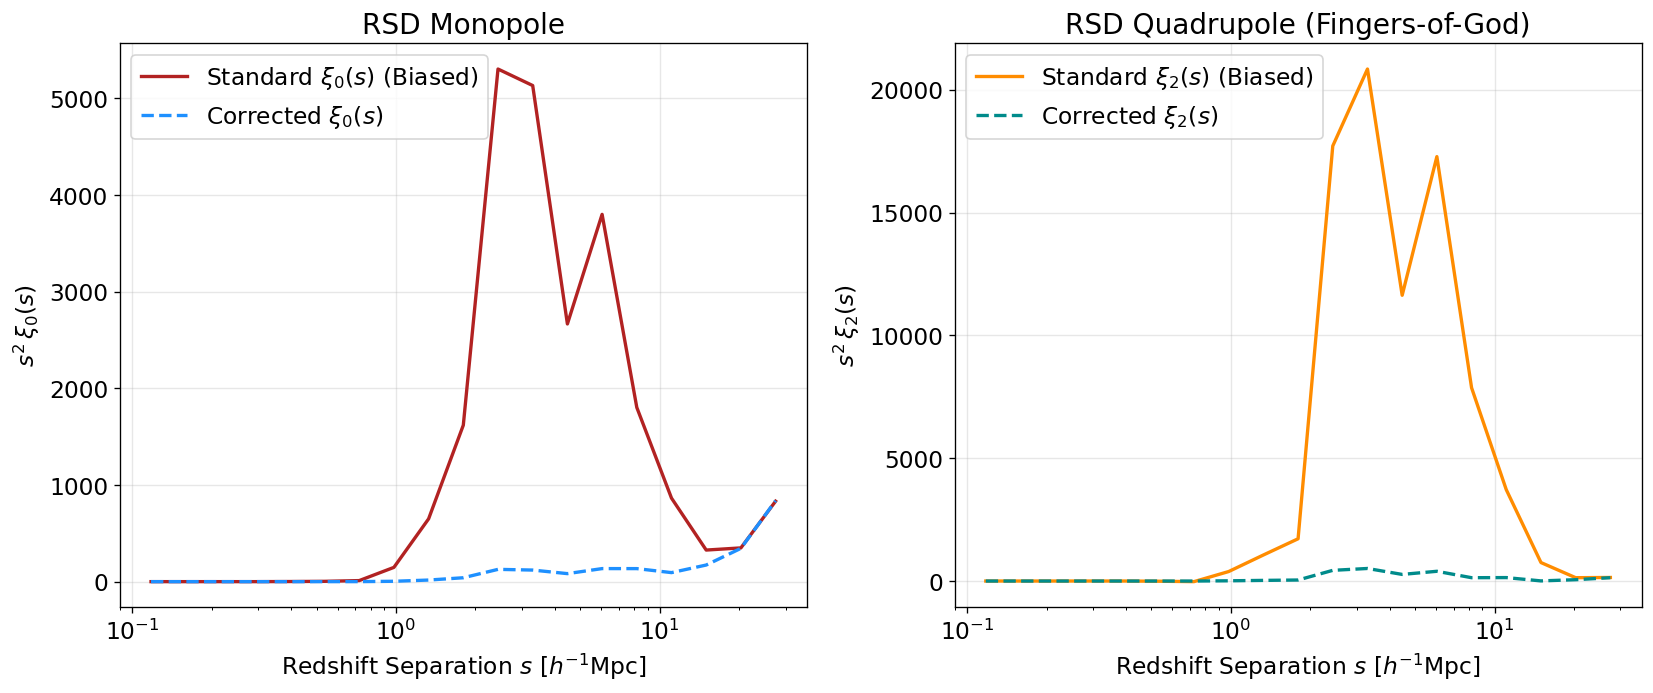

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Plot Monopole
ax1.plot(s_mid, s_mid**2 * xi0_std, label=r"Standard $\xi_0(s)$ (Biased)", color='firebrick', lw=2)
ax1.plot(s_mid, s_mid**2 * xi0_corr, label=r"Corrected $\xi_0(s)$", color='dodgerblue', lw=2, ls='--')
ax1.set_xscale('log')
ax1.set_xlabel(r'Redshift Separation $s \ [h^{-1}\mathrm{Mpc}]$')
ax1.set_ylabel(r'$s^2 \, \xi_0(s)$')
ax1.set_title("RSD Monopole")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Quadrupole
ax2.plot(s_mid, s_mid**2 * xi2_std, label=r"Standard $\xi_2(s)$ (Biased)", color='darkorange', lw=2)
ax2.plot(s_mid, s_mid**2 * xi2_corr, label=r"Corrected $\xi_2(s)$", color='darkcyan', lw=2, ls='--')
ax2.set_xscale('log')
ax2.set_xlabel(r'Redshift Separation $s \ [h^{-1}\mathrm{Mpc}]$')
ax2.set_ylabel(r'$s^2 \, \xi_2(s)$')
ax2.set_title("RSD Quadrupole (Fingers-of-God)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()